In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



https://huggingface.co/datasets/dair-ai/emotion

In [2]:
import pyarrow as pa
import pyarrow.dataset as ds

print(pa.__version__)
print("PyArrow OK")

21.0.0
PyArrow OK


In [3]:
#dataset load
from datasets import load_dataset

c:\Users\psran\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
emotion_dataset = emotion_dataset = load_dataset('dair-ai/emotion')
train_text =   emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text =  emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [5]:
label_name = emotion_dataset['train'].features['label'].names

In [6]:
label_name

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [7]:
for i in train_label:
    print(label_name[i])

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love
sadness
joy
anger
sadness
joy
joy
sadness
sadness
sadness
fear
anger
fear
joy
joy
anger
sadness
sadness
sadness
anger
joy
joy
fear
surprise
anger
joy
joy
joy
joy
anger
joy
joy
joy
joy
joy
sadness
sadness
joy
love
joy
anger
joy
sadness
anger
fear
joy
sadness
sadness
surprise
joy
joy
joy
love
fear
fear
surprise
anger
anger
sadness
love
joy
sadness
sadness
joy
sadness
sadness
sadness
joy
joy
joy
anger
sadness
anger
anger
anger
joy
joy
joy
joy
sadness
fear
love
anger
sadness
anger
love
sadness
joy
joy
sadness
anger
love
joy
joy
joy
sadness
joy
joy
joy
joy
sadness
joy
joy
love
sadness
sadness
joy
joy
sadness
joy
joy
fear
fear
fear
sadness
love
joy
joy
love
fear
surprise
joy
joy
joy
joy
anger
fear
joy
anger
love
anger
sadness
joy
sadness
anger
joy
surprise
sadness
anger
anger
sadness
joy
fear
joy
joy
fear
sadness
surprise
surprise
joy
anger
fear
anger
sadness
anger
sadness
fear
sadness
joy
surprise
fear
joy
anger
joy
anger
joy
f

In [8]:
df_train = pd.DataFrame(
    {
        'text' : train_text,
        'label' : [label_name[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_name[i] for i in test_label]
    }
)


EDA

In [9]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

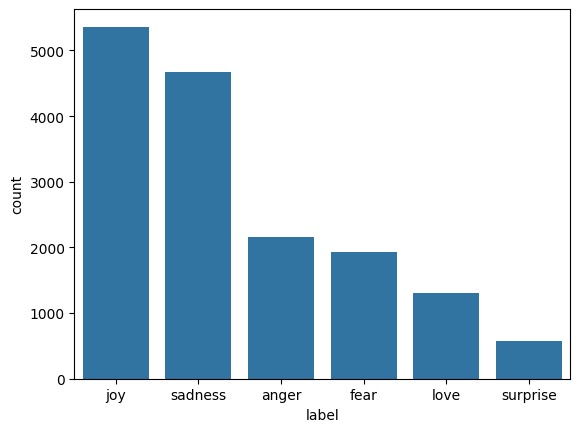

In [10]:
sns.countplot(x='label', data=df_train, order=['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'])

Preprocessing - Using NLP

In [11]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 50

# Tokenizer
tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<unk>"
)

tokenizer.fit_on_texts(df_train["text"])

# Convert text to sequences
train_sequence = tokenizer.texts_to_sequences(df_train["text"])
test_sequence = tokenizer.texts_to_sequences(df_test["text"])

# Padding
padded_train_sequence = pad_sequences(
    train_sequence,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

padded_test_sequence = pad_sequences(
    test_sequence,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

# Labels
train_labels = np.asarray(train_label, dtype=np.int32)
test_labels = np.asarray(test_label, dtype=np.int32)

# Check shapes
print("X_train:", padded_train_sequence.shape)
print("y_train:", train_labels.shape)

print("X_test:", padded_test_sequence.shape)
print("y_test:", test_labels.shape)

num_classes = len(np.unique(train_labels))

print("Number of classes:", num_classes)
print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

X_train: (16000, 50)
y_train: (16000,)
X_test: (2000, 50)
y_test: (2000,)
Number of classes: 6
Vocabulary Size: 15213
Max Sentence Length: 50


Shared Training Utilities

In [12]:
from sklearn.utils import class_weight

class_weight = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_label),
    y       = train_label 
)

class_weight_dict =  dict(enumerate(class_weight))

In [13]:
from tensorflow.keras.callbacks import  EarlyStopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights = True
)

Models

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU
rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

c:\Users\psran\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [15]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.1573 - loss: 2.0546 - val_accuracy: 0.0340 - val_loss: 1.7971
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.1467 - loss: 1.8918 - val_accuracy: 0.0795 - val_loss: 1.7678
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.1322 - loss: 1.8228 - val_accuracy: 0.1370 - val_loss: 1.8073
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.1359 - loss: 1.8083 - val_accuracy: 0.1120 - val_loss: 1.7852
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.1347 - loss: 1.8041 - val_accuracy: 0.1375 - val_loss: 1.7621
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.1399 - loss: 1.8008 - val_accuracy: 0.2915 - val_loss: 1.7608
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.1523 - loss: 1.8011 - val_accuracy: 0.1375 - val_loss: 1.7889
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.1416 - loss: 1.8033 - 

Model 2 — Standard LSTM

In [16]:
lstm_model =Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 91ms/step - accuracy: 0.1574 - loss: 1.7954 - val_accuracy: 0.2910 - val_loss: 1.7686
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 93ms/step - accuracy: 0.1524 - loss: 1.7933 - val_accuracy: 0.1370 - val_loss: 1.7877
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.1471 - loss: 1.7929 - val_accuracy: 0.3340 - val_loss: 1.7911
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 91ms/step - accuracy: 0.1905 - loss: 1.7905 - val_accuracy: 0.1470 - val_loss: 1.8038
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.2910 - loss: 1.7686
LSTM Loss: 1.7685937881469727
LSTM Accuracy: 0.29100000858306885


In [17]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 82ms/step - accuracy: 0.1709 - loss: 1.7968 - val_accuracy: 0.0810 - val_loss: 1.8031
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 81ms/step - accuracy: 0.1654 - loss: 1.7952 - val_accuracy: 0.0795 - val_loss: 1.8055
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.1673 - loss: 1.7939 - val_accuracy: 0.1130 - val_loss: 1.7986
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.1516 - loss: 1.7930 - val_accuracy: 0.2890 - val_loss: 1.7317
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.1825 - loss: 1.7908 - val_accuracy: 0.0535 - val_loss: 1.8105
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - accuracy: 0.1891 - loss: 1.7761 - val_accuracy: 0.1135 - val_loss: 1.8621
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.2224 - loss: 1.7398 - val_accuracy: 0.1275 - val_loss: 1.8141
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2890 - loss: 1.7317
GRU Loss: 1.7316

Phase 1 Ranking & Selection

In [18]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy' : [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Test Accuracy', ascending=False)

result_df

,Model,Test Loss,Test Accuracy
0,RNN,1.760765,0.2915
1,LSTM,1.768594,0.2910
2,GRU,1.731690,0.2890


Phase 2 — Advanced Bidirectional GRU

Model 4 — Advanced Stacked Bidirectional GRU

In [19]:
from tensorflow.keras.layers import Bidirectional
BiGRU = Sequential([
    Embedding(input_dim= max_words, output_dim=300, input_length=50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

BiGRU.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
BiGRU.summary()

c:\Users\psran\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 109s 200ms/step - accuracy: 0.5857 - loss: 1.0323 - val_accuracy: 0.8815 - val_loss: 0.3641
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 101s 203ms/step - accuracy: 0.9183 - loss: 0.2382 - val_accuracy: 0.9090 - val_loss: 0.2773
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 96s 193ms/step - accuracy: 0.9423 - loss: 0.1510 - val_accuracy: 0.9200 - val_loss: 0.2363
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 100s 201ms/step - accuracy: 0.9613 - loss: 0.1016 - val_accuracy: 0.9140 - val_loss: 0.2466
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 97s 194ms/step - accuracy: 0.9669 - loss: 0.0928 - val_accuracy: 0.9125 - val_loss: 0.2561
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 107s 213ms/step - accuracy: 0.9751 - loss: 0.0725 - val_accuracy: 0.9160 - val_loss: 0.3153


In [21]:
padded_test_sequence = np.array(padded_test_sequence)
test_label = np.array(test_label)
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_label)
print(f'BiGRU Loss : {BiGRU_loss}')
print(f'BiGRU Accuracy : {BiGRU_accuracy}')


63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9200 - loss: 0.2363
BiGRU Loss : 0.2363463193178177
BiGRU Accuracy : 0.9200000166893005


63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step


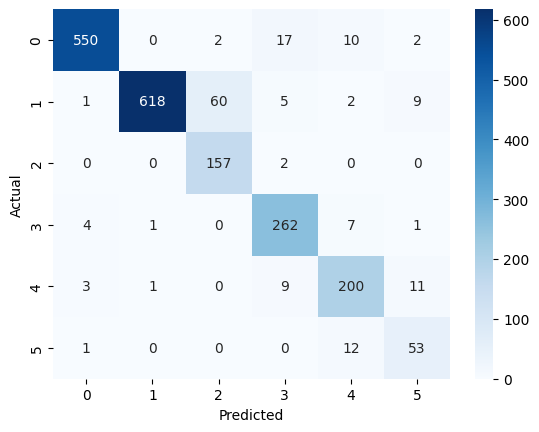

In [22]:
from sklearn.metrics import confusion_matrix

BiGRU_prediction = BiGRU.predict(padded_test_sequence)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert probabilities to class labels
BiGRU_pred_classes = np.argmax(BiGRU_prediction, axis=1)

# Confusion matrix
cm = confusion_matrix(test_label, BiGRU_pred_classes)

# Heatmap plot
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
sample_text = [
    "The morning sun shines bright:",  
    "Birds sing with pure delight.",  
    "Each day brings a brand new story",  
    "Life unfolds in gentle glory."  

]

sample_sequence = tokenizer.texts_to_sequences(sample_text)
sample_padded_sequence = pad_sequences(sample_sequence, maxlen=50, padding='post', truncating='post')

sample_prediction = np.argmax(BiGRU.predict(sample_padded_sequence), axis =1)
sample_prediction
for i in range(len(sample_text)):
    print(f'Text: {sample_text[i]}\nPredicted Emotion: {label_name[sample_prediction[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Text: The morning sun shines bright:
Predicted Emotion: anger
Text: Birds sing with pure delight.
Predicted Emotion: fear
Text: Each day brings a brand new story
Predicted Emotion: fear
Text: Life unfolds in gentle glory.
Predicted Emotion: love


Save Model

In [24]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)
     